In [1]:
!pip install pyspark

In [13]:
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
spark = SparkSession.builder.appName("MovieRecommendationSystem").getOrCreate()

In [17]:
ratings = spark.read.csv("/content/ratings.csv", header=True, inferSchema=True)
movies = spark.read.csv("/content/movies.csv", header=True, inferSchema=True)

print("✅ Data Loaded Successfully")

✅ Data Loaded Successfully


In [18]:
ratings.show(5)
ratings.printSchema()
ratings.describe().show()

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
+------+-------+------+---------+
only showing top 5 rows

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

+-------+------------------+----------------+------------------+--------------------+
|summary|            userId|         movieId|            rating|           timestamp|
+-------+------------------+----------------+------------------+--------------------+
|  count|            100836|          100836|            100836|              100836|
|   mean|326.12756356856676|19435.2957177992| 3.501556983616962|1.2059460873684695E9|
| stddev| 182.6184914635004|35530.9871987003|1.0425292390606342|2.16261035

In [19]:
ratings = ratings.dropna()

In [20]:
train, test = ratings.randomSplit([0.8, 0.2], seed=42)

In [21]:
print("\n🎬 Training ALS (Collaborative Filtering) Model...")

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    nonnegative=True,
    coldStartStrategy="drop"
)
als_model = als.fit(train)

als_predictions = als_model.transform(test)


🎬 Training ALS (Collaborative Filtering) Model...


In [22]:
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse_als = evaluator.evaluate(als_predictions)
print(f"✅ ALS Model RMSE: {rmse_als}")

✅ ALS Model RMSE: 0.8769591746798594


In [23]:
als_model.write().overwrite().save("/content/als_movie_model")

In [24]:
print("\n🤖 Training Traditional ML Model (Linear Regression)...")


🤖 Training Traditional ML Model (Linear Regression)...


In [28]:
assembler = VectorAssembler(inputCols=["userId", "movieId"], outputCol="features")
train_lr = assembler.transform(train)
test_lr = assembler.transform(test)

In [29]:
lr = LinearRegression(featuresCol="features", labelCol="rating")
lr_model = lr.fit(train_lr)

In [30]:
lr_predictions = lr_model.transform(test_lr)

In [31]:
rmse_lr = evaluator.evaluate(lr_predictions)
print(f"✅ Linear Regression RMSE: {rmse_lr}")

✅ Linear Regression RMSE: 1.0487758392647812


In [32]:
print("\n📊 Model Comparison:")
print(f"ALS Collaborative Filtering RMSE: {rmse_als}")
print(f"Linear Regression RMSE:          {rmse_lr}")


📊 Model Comparison:
ALS Collaborative Filtering RMSE: 0.8769591746798594
Linear Regression RMSE:          1.0487758392647812


In [33]:
models = ["ALS (Collaborative Filtering)", "Linear Regression"]
rmse_values = [rmse_als, rmse_lr]

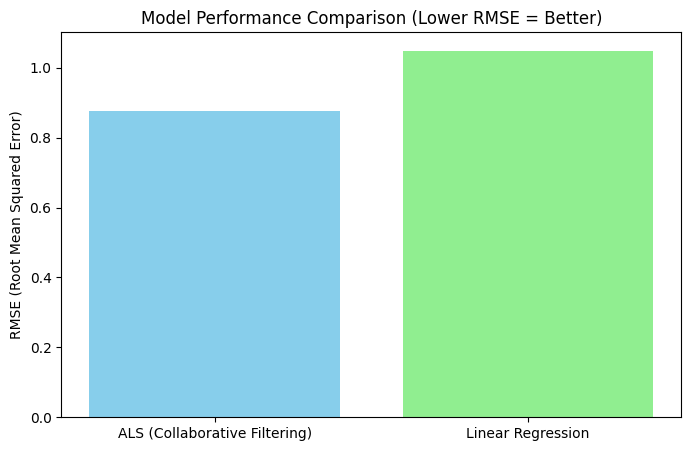

In [34]:
plt.figure(figsize=(8, 5))
plt.bar(models, rmse_values, color=['skyblue', 'lightgreen'])
plt.title("Model Performance Comparison (Lower RMSE = Better)")
plt.ylabel("RMSE (Root Mean Squared Error)")
plt.show()

In [35]:
print("\n🎥 Generating Recommendations using ALS...")

user_recs = als_model.recommendForAllUsers(5)
user_recs.show(5, truncate=False)


🎥 Generating Recommendations using ALS...
+------+-------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                  |
+------+-------------------------------------------------------------------------------------------------+
|1     |[{33649, 5.825862}, {177593, 5.6930156}, {78836, 5.586123}, {26171, 5.582576}, {4642, 5.5809073}]|
|2     |[{26171, 5.181942}, {1274, 5.049619}, {33649, 4.9149837}, {32892, 4.910966}, {74754, 4.8962646}] |
|3     |[{417, 4.932218}, {6835, 4.8808}, {5746, 4.8808}, {5181, 4.8521194}, {74754, 4.846381}]          |
|4     |[{132333, 5.284542}, {3494, 5.237455}, {8542, 5.2232137}, {89118, 5.141449}, {5915, 5.1375337}]  |
|5     |[{4642, 4.977258}, {1212, 4.9371357}, {6732, 4.8739443}, {3083, 4.8545165}, {177593, 4.8038783}] |
+------+---------------------------------------------------------------------------------------------

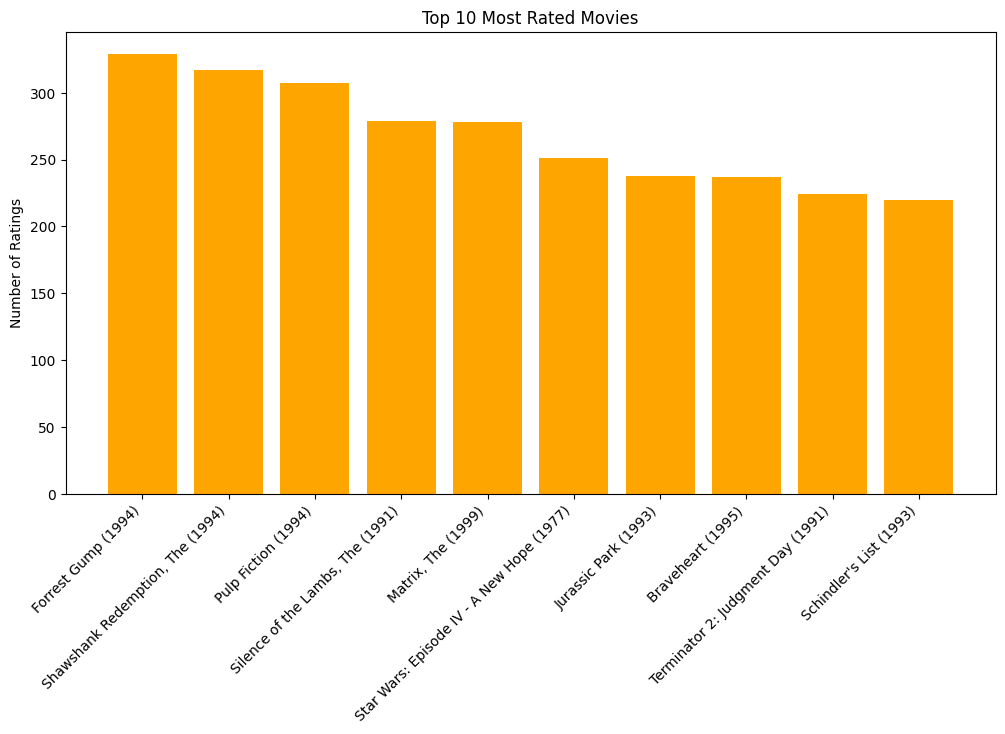

In [36]:
ratings_pd = ratings.toPandas()
top_movies = ratings_pd.groupby("movieId")["rating"].count().sort_values(ascending=False).head(10).reset_index()
movies_pd = pd.read_csv("/content/movies.csv")
top_movies = top_movies.merge(movies_pd, on="movieId")

plt.figure(figsize=(12,6))
plt.bar(top_movies['title'], top_movies['rating'], color='orange')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Ratings")
plt.title("Top 10 Most Rated Movies")
plt.show()

In [38]:
spark.stop()
